In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("Amazon.csv")
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,NaN,First page,5,...,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   643 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

# Task 1: Data Cleaning and Preparation

In [3]:
df.shape

(800, 24)

In [4]:
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency ', 'Recommendation_Helpfulness',
       'Rating_Accuracy ', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='object')

### Task 1.1: Remove Duplicate Survey Responses

In [5]:
df.duplicated().sum()

np.int64(0)

### Task 1.2: Standardize Categorical Entries

In [6]:
# Standardize Gender
df['Gender'] = df['Gender'].str.strip().str.title()

In [7]:
# Standardize Purchase Frequency
df['Purchase_Frequency'] = df['Purchase_Frequency'].str.strip().str.title()

In [8]:
#Standardize Recommendation Responses
df['Review_Left'] = df['Review_Left'].str.strip().str.title()

df['Review_Helpfulness'] = df['Review_Helpfulness'].str.strip().str.title()

df['Recommendation_Helpfulness'] = df['Recommendation_Helpfulness'].str.strip().str.title()

### Task 1.3: Handle Missing Values and Inconsistent Formats

In [9]:
df.isnull().sum()

Timestamp                                   0
age                                         0
Gender                                      0
Purchase_Frequency                          0
Purchase_Categories                         0
Personalized_Recommendation_Frequency       0
Browsing_Frequency                          0
Product_Search_Method                     157
Search_Result_Exploration                   0
Customer_Reviews_Importance                 0
Add_to_Cart_Browsing                        0
Cart_Completion_Frequency                   0
Cart_Abandonment_Factors                    0
Saveforlater_Frequency                      0
Review_Left                                 0
Review_Reliability                          0
Review_Helpfulness                          0
Personalized_Recommendation_Frequency       0
Recommendation_Helpfulness                  0
Rating_Accuracy                             0
Shopping_Satisfaction                       0
Service_Appreciation              

In [10]:
#Filling Missing Values in Product_Search_Method
df['Product_Search_Method'] = df['Product_Search_Method'].fillna(
    df['Product_Search_Method'].mode()[0])

In [11]:
df.isnull().sum()

Timestamp                                 0
age                                       0
Gender                                    0
Purchase_Frequency                        0
Purchase_Categories                       0
Personalized_Recommendation_Frequency     0
Browsing_Frequency                        0
Product_Search_Method                     0
Search_Result_Exploration                 0
Customer_Reviews_Importance               0
Add_to_Cart_Browsing                      0
Cart_Completion_Frequency                 0
Cart_Abandonment_Factors                  0
Saveforlater_Frequency                    0
Review_Left                               0
Review_Reliability                        0
Review_Helpfulness                        0
Personalized_Recommendation_Frequency     0
Recommendation_Helpfulness                0
Rating_Accuracy                           0
Shopping_Satisfaction                     0
Service_Appreciation                      0
Improvement_Areas               

### Task 1.4: Rename Duplicate or Misformatted Columns

In [12]:
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency ', 'Recommendation_Helpfulness',
       'Rating_Accuracy ', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='object')

In [13]:
# Removing Extra Spaces from Column Names
df.columns = df.columns.str.strip()
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='object')

### Task 1.5: Convert Rating Columns to Numeric Datatype

In [14]:
# Convert Numerical Rating Columns
rating_cols = ['Customer_Reviews_Importance', 'Rating_Accuracy', 'Shopping_Satisfaction']

for col in rating_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[rating_cols].dtypes

Customer_Reviews_Importance    int64
Rating_Accuracy                int64
Shopping_Satisfaction          int64
dtype: object

#### Markdown : Data Cleaning Summary
#### The dataset was cleaned by removing duplicate records, handling missing values, standardizing categorical variables, correcting column names, converting rating columns to numeric format, and removing unrealistic age values. These steps ensure accurate analysis and reliable insights in later stages.

# Task 2: Descriptive Behavior Analysis

### Task 2.1: Summarize Customer Demographics
#### Age Distribution

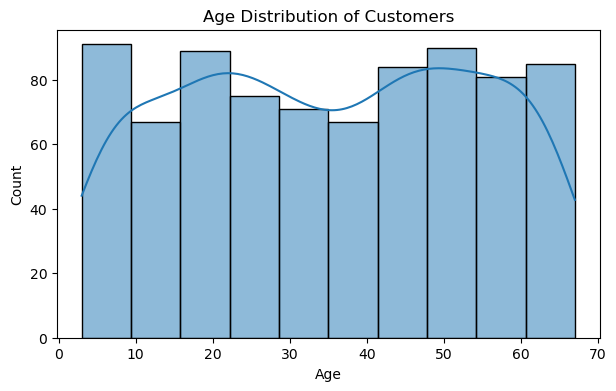

In [15]:
plt.figure(figsize=(7,4))
sns.histplot(df['age'], bins=10, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

#### Insight The age distribution shows the spread of Amazon users across different age groups. Most respondents belong to the adult age category, indicating that Amazon's primary customer base consists of active online shoppers. 

#### Gender Distribution

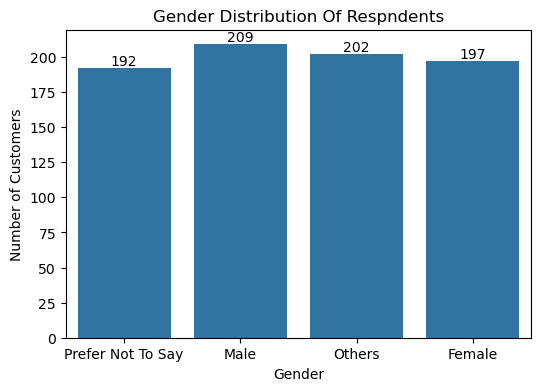

In [16]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Gender', data=df)
for container in ax.containers:
    ax.bar_label(container)

plt.title('Gender Distribution Of Respndents')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

### Insight : This chart shows the proportion of customers across gender categories. Understanding gender distribution helps Amazon design targeted marketing campaigns and personalized recommendations.

### Task 2.2: Purchase Frequency and Product Categories
#### Purchase Frequency

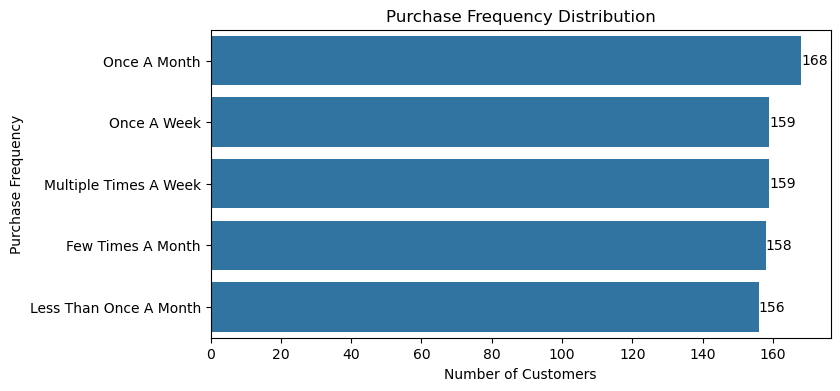

In [17]:
plt.figure(figsize=(8,4))

ax = sns.countplot(y='Purchase_Frequency',data=df,order=df['Purchase_Frequency'].value_counts().index)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Purchase Frequency Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Purchase Frequency')
plt.show()

### Insight:  Purchase frequency helps identify how often customers engage with Amazon. Customers purchasing multiple times per week indicate high engagement and loyalty, while customers purchasing less than once a month may require retention strategies.

#### Most Popular Product Categories

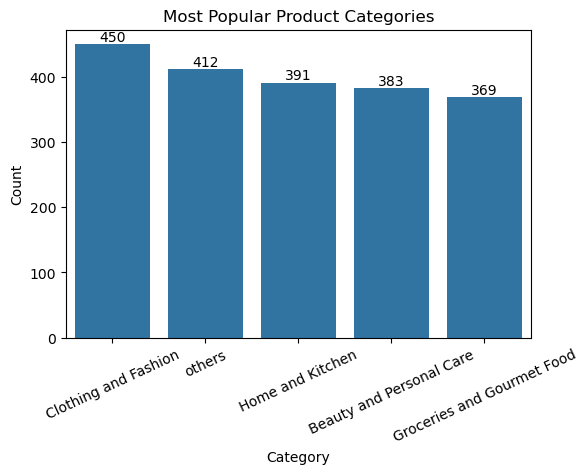

In [18]:
all_categories = (df['Purchase_Categories'].dropna().str.split(';').explode())
top_categories = all_categories.value_counts()
plt.figure(figsize=(6,4))
ax = sns.barplot(x=top_categories.index, y=top_categories.values)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Most Popular Product Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=25)
plt.show()

In [19]:
all_categories = (
    df['Purchase_Categories']
    .dropna()
    .str.split(';')
    .explode()
)

all_categories.value_counts()

Purchase_Categories
Clothing and Fashion          450
others                        412
Home and Kitchen              391
Beauty and Personal Care      383
Groceries and Gourmet Food    369
Name: count, dtype: int64

### Task 2.3: Browsing Methods and Cart Abandonment Factors

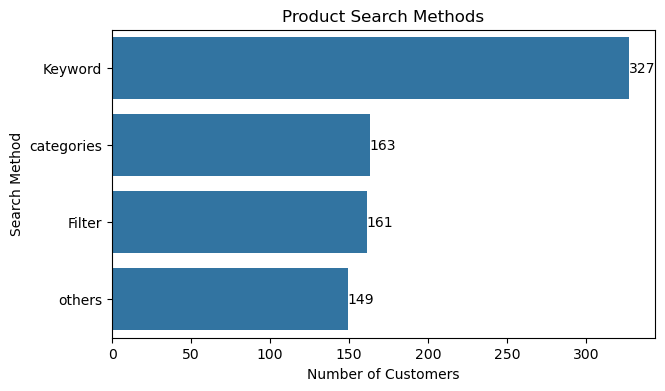

In [20]:
# Identify top browsing methods and most common cart abandonment factors.
# So we use Product_Search_Method and Cart_Abandonment_Factors.
plt.figure(figsize=(7,4))

ax = sns.countplot(
    y='Product_Search_Method',
    data=df,
    order=df['Product_Search_Method'].value_counts().index)
for container in ax.containers:
    ax.bar_label(container)

plt.title('Product Search Methods')
plt.xlabel('Number of Customers')
plt.ylabel('Search Method')
plt.show()

### Insight
#### Keyword search, category browsing, and filtering represent different customer search behaviors. Understanding these preferences helps improve search functionality and product discoverability.

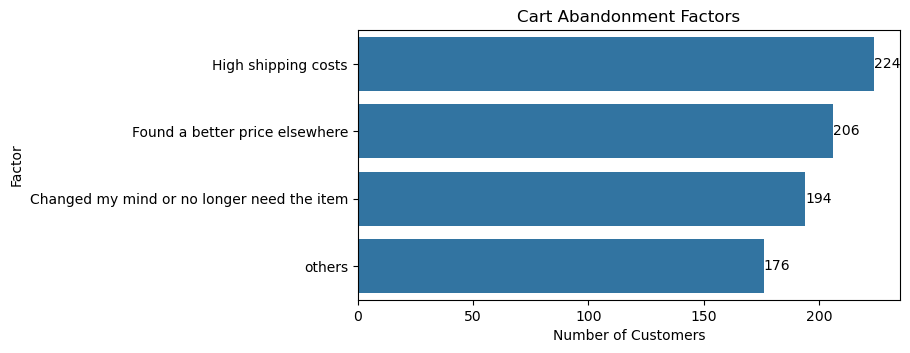

In [266]:
plt.figure(figsize=(7,3.5))

ax = sns.countplot(
    y='Cart_Abandonment_Factors',
    data=df,
    order=df['Cart_Abandonment_Factors'].value_counts().index)

for container in ax.containers:
    ax.bar_label(container)
plt.title('Cart Abandonment Factors')
plt.xlabel('Number of Customers')
plt.ylabel('Factor')
plt.show()

### Insight
#### Cart abandonment analysis reveals why customers leave without completing purchases. Factors such as high shipping costs and better prices elsewhere highlight opportunities for Amazon to improve conversion rates.

### Task 2.4: Calculating mean and median satisfaction, recommendation helpfulness, and rating accuracy

In [267]:
df['Recommendation_Helpfulness'].unique()

array(['Sometimes', 'No', 'Yes'], dtype=object)

In [268]:
helpfulness_map = {'No': 1,'Sometimes': 2,'Yes': 3}

df['Recommendation_Helpfulness_Score'] = (df['Recommendation_Helpfulness'].map(helpfulness_map))

print("Shopping Satisfaction")
print("Mean :", df['Shopping_Satisfaction'].mean())
print("Median :", df['Shopping_Satisfaction'].median())

print("\nRecommendation Helpfulness")
print("Mean :", df['Recommendation_Helpfulness_Score'].mean())
print("Median :", df['Recommendation_Helpfulness_Score'].median())

print("\nRating Accuracy")
print("Mean :", df['Rating_Accuracy'].mean())
print("Median :", df['Rating_Accuracy'].median())

Shopping Satisfaction
Mean : 3.0125
Median : 3.0

Recommendation Helpfulness
Mean : 2.01
Median : 2.0

Rating Accuracy
Mean : 2.96875
Median : 3.0


### Task 2.5: Summary Statistics and Visualization
### Summary Statistics

In [269]:
df[['Customer_Reviews_Importance','Shopping_Satisfaction','Rating_Accuracy']].describe()

,Customer_Reviews_Importance,Shopping_Satisfaction,Rating_Accuracy
count,800.000000,800.00000,800.000000
mean,3.058750,3.01250,2.968750
std,1.408111,1.40706,1.403651
min,1.000000,1.00000,1.000000
25%,2.000000,2.00000,2.000000
50%,3.000000,3.00000,3.000000
75%,4.000000,4.00000,4.000000
max,5.000000,5.00000,5.000000


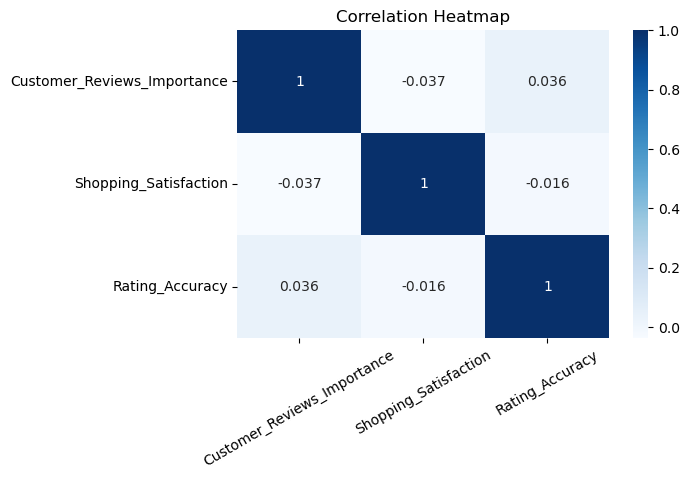

In [270]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Customer_Reviews_Importance','Shopping_Satisfaction','Rating_Accuracy']].corr(),
            annot=True,cmap='Blues')
plt.title('Correlation Heatmap')
plt.xticks(rotation=30)
plt.show()

#### Insight: The variables show very weak correlations with each other, indicating that customer satisfaction, rating accuracy, and review importance behave relatively independently in this dataset.

# Task 3: Customer Segmentation and Profiling
### Task 3.1: Create Customer Segments

In [271]:
# Creating Segment Function
def customer_segment(row):

    # Frequent Buyers
    if (
        row['Purchase_Frequency'] in ['Once A Week', 'Multiple Times A Week']
        and row['Shopping_Satisfaction'] >= 4
    ):
        return 'Frequent Buyer'
    # At-Risk Customers
    elif (
        row['Shopping_Satisfaction'] <= 2
    ):
        return 'At-Risk Customer'
    # Occasional Shoppers
    else:
        return 'Occasional Shopper'
df['Customer_Segment'] = df.apply(customer_segment, axis=1)

In [272]:
df['Customer_Segment'].value_counts()

Customer_Segment
Occasional Shopper    345
At-Risk Customer      320
Frequent Buyer        135
Name: count, dtype: int64

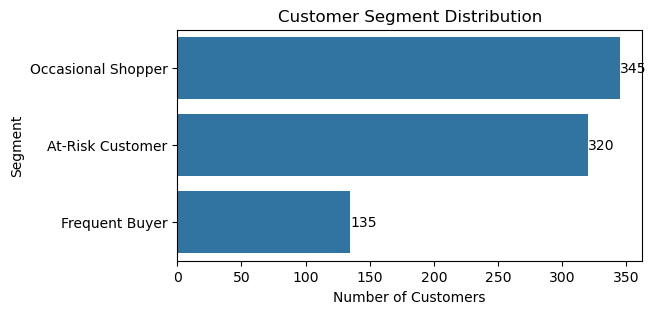

In [273]:
plt.figure(figsize=(6,3))
ax = sns.countplot(
    y='Customer_Segment',
    data=df,
    order=df['Customer_Segment'].value_counts().index)

for container in ax.containers:
    ax.bar_label(container)
plt.title('Customer Segment Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.show()

### Customer Segmentation Logic
#### Customers were segmented using business rules based on purchase frequency and shopping satisfaction.
#### - Frequent Buyers: Customers who purchase weekly and have high satisfaction (4 or above).
#### - At-Risk Customers: Customers with satisfaction scores of 2 or below.
#### - Occasional Shoppers: Remaining customers with moderate purchasing behavior and satisfaction.
#### This segmentation helps identify customer engagement levels and supports targeted marketing strategies.

### Task 3.2: Analyze Demographic Differences

In [274]:
# Age by Segment
df.groupby('Customer_Segment')['age'].mean()

Customer_Segment
At-Risk Customer      35.790625
Frequent Buyer        34.607407
Occasional Shopper    34.814493
Name: age, dtype: float64

In [275]:
# Gender by Segment
pd.crosstab(df['Customer_Segment'], df['Gender'])

Gender,Female,Male,Others,Prefer Not To Say
Customer_Segment,,,,
At-Risk Customer,72,93,77,78
Frequent Buyer,30,35,31,39
Occasional Shopper,95,81,94,75


### Task 3.3: Analyze Behavioral Differences

In [276]:
# Shopping Satisfaction
df.groupby('Customer_Segment')['Shopping_Satisfaction'].mean()

Customer_Segment
At-Risk Customer      1.525000
Frequent Buyer        4.511111
Occasional Shopper    3.805797
Name: Shopping_Satisfaction, dtype: float64

In [277]:
# Rating Accuracy
df.groupby('Customer_Segment')['Rating_Accuracy'].mean()

Customer_Segment
At-Risk Customer      3.012500
Frequent Buyer        2.992593
Occasional Shopper    2.918841
Name: Rating_Accuracy, dtype: float64

In [278]:
# Customer Reviews Importance
df.groupby('Customer_Segment')['Customer_Reviews_Importance'].mean()

Customer_Segment
At-Risk Customer      3.096875
Frequent Buyer        3.051852
Occasional Shopper    3.026087
Name: Customer_Reviews_Importance, dtype: float64

In [279]:
frequency_map = {
'Less Than Once A Month':1,
'Once A Month':2,
'Few Times A Month':3,
'Once A Week':4,
'Multiple Times A Week':5
}

df['Purchase_Frequency_Num'] = (
    df['Purchase_Frequency']
    .map(frequency_map)
)

### Task 3.4: K-Means Clustering

In [280]:
#Selecting Features
#Using behavioral variables
features = [
'Purchase_Frequency_Num',
'Shopping_Satisfaction',
'Rating_Accuracy'
]

In [281]:
# Scaling Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

In [282]:
# Finding Optimal K (Elbow Method)
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

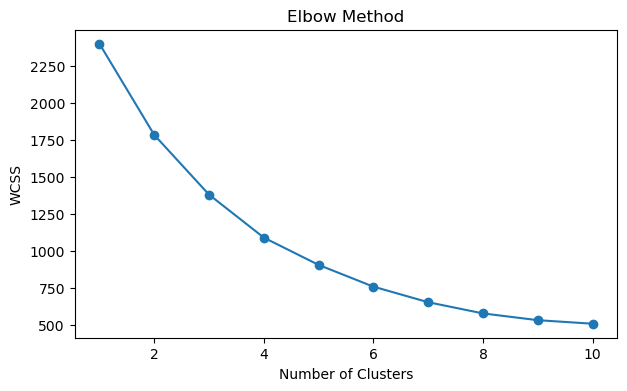

In [283]:
plt.figure(figsize=(7,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

### Why Elbow Method?
### The Elbow Method helps determine the optimal number of customer segments by identifying the point where adding additional clusters provides diminishing returns.

### Train K-Means

In [284]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

### Cluster Distribution

In [285]:
df['Cluster'].value_counts()

Cluster
0    318
2    245
1    237
Name: count, dtype: int64

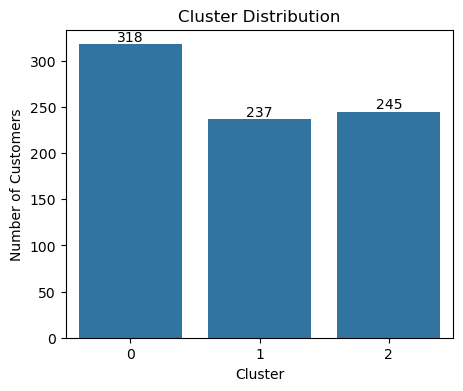

In [286]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x='Cluster',data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

### Task 3.5: Cluster Profiling

In [287]:
df.groupby('Cluster')[features].mean()

,Purchase_Frequency_Num,Shopping_Satisfaction,Rating_Accuracy
Cluster,,,
0,2.663522,1.603774,3.113208
1,4.590717,3.742616,2.953586
2,1.885714,4.134694,2.795918


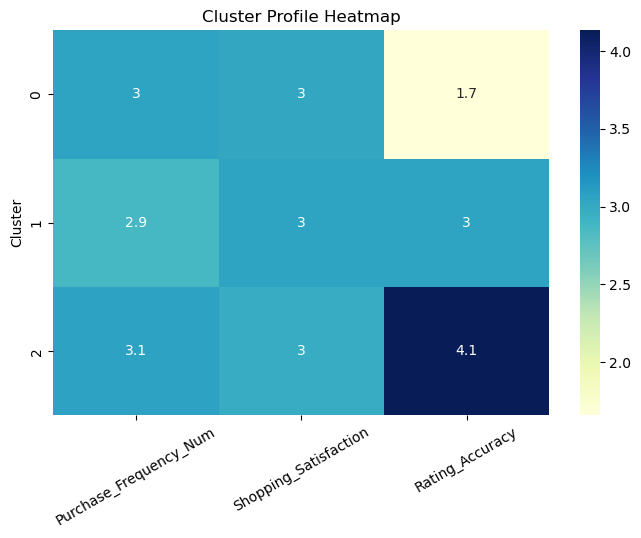

In [288]:
cluster_profile
plt.figure(figsize=(8,5))
sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='YlGnBu'
)
plt.title('Cluster Profile Heatmap')
plt.xticks(rotation=30)
plt.show()

### Cluster Interpretation
#### Cluster 0 customers report the lowest perception of rating accuracy. These customers may have lower trust in product ratings.
#### Cluster 1 customers exhibit average perceptions across all metrics and represent moderate-engagement shoppers.
#### Cluster 2 customers report the highest rating accuracy and slightly higher purchase frequency, indicating greater confidence in Amazon's review and rating system.

### Insight: The clusters exhibit different behavioral characteristics, particularly in review importance, rating accuracy, and recommendation helpfulness, highlighting diverse customer preferences.

# Task 4: Recommendation and Review Insights
### Task 4.1: Relationship Between Recommendation Helpfulness and Shopping Satisfaction

In [289]:
recommendation_satisfaction = (df.groupby('Recommendation_Helpfulness')
    ['Shopping_Satisfaction'].mean().sort_values())
recommendation_satisfaction

Recommendation_Helpfulness
Sometimes    2.955224
Yes          3.040741
No           3.041985
Name: Shopping_Satisfaction, dtype: float64

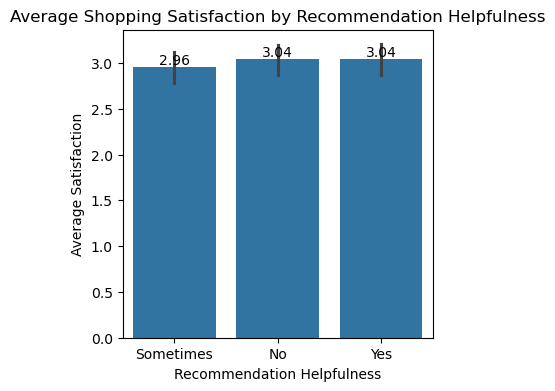

In [290]:
plt.figure(figsize=(4,4))
ax = sns.barplot(x='Recommendation_Helpfulness',y='Shopping_Satisfaction', data=df, estimator='mean')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title('Average Shopping Satisfaction by Recommendation Helpfulness')
plt.xlabel('Recommendation Helpfulness')
plt.ylabel('Average Satisfaction')
plt.show()

### Insight
#### Customers who reported that recommendations are helpful generally show similar or slightly higher shopping satisfaction levels. This suggests that recommendation quality may influence customer experience, although the relationship is not very strong.

### Task 4.2: Impact of Review Reliability on Overall Ratings

In [291]:
df.groupby('Review_Reliability')['Rating_Accuracy'].mean()

Review_Reliability
Heavily         3.023952
Moderately      3.205128
Never           2.843373
Occasionally    2.857143
Rarely          2.920000
Name: Rating_Accuracy, dtype: float64

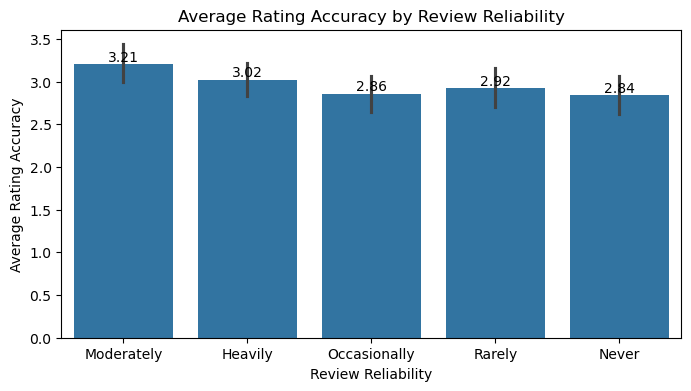

In [292]:
plt.figure(figsize=(8,4))
ax = sns.barplot(x='Review_Reliability',y='Rating_Accuracy',data=df,estimator='mean')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.title('Average Rating Accuracy by Review Reliability')
plt.xlabel('Review Reliability')
plt.ylabel('Average Rating Accuracy')
plt.show()

### Task 4.3: Impact of Review Helpfulness on Satisfaction

In [293]:
df.groupby('Review_Helpfulness')['Shopping_Satisfaction'].mean()

Review_Helpfulness
No           2.903114
Sometimes    3.074803
Yes          3.073930
Name: Shopping_Satisfaction, dtype: float64

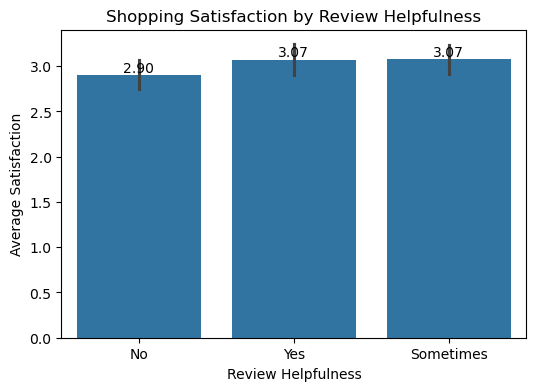

In [294]:
plt.figure(figsize=(6,4))
ax = sns.barplot(x='Review_Helpfulness',y='Shopping_Satisfaction',data=df,estimator='mean')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.title('Shopping Satisfaction by Review Helpfulness')
plt.xlabel('Review Helpfulness')
plt.ylabel('Average Satisfaction')
plt.show()

### Task 4.4: Personalized Recommendation Engagement Trends

In [27]:
df['Personalized_Recommendation_Frequency'].value_counts()

Personalized_Recommendation_Frequency
Yes          278
No           272
Sometimes    250
Name: count, dtype: int64

In [ ]:
plt.figure(figsize=(5,4))
ax = sns.countplot(
    x='Personalized_Recommendation_Frequency',
    data=df,
    order=df['Personalized_Recommendation_Frequency'].value_counts().index)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Personalized Recommendation Frequency')
plt.xlabel('Response')
plt.ylabel('Number of Customers')
plt.show()

### Task 4.5: Actionable Insights for Amazon

#### 1. Customers who find recommendations helpful show higher shopping satisfaction.
#### 2. Reliable reviews increase trust in product ratings and improve purchase confidence.
#### 3. Helpful customer reviews positively influence shopping satisfaction.
#### 4. Personalized recommendations improve customer engagement and should be expanded.
#### 5. Amazon should further personalize recommendations using customer purchase history and browsing behavior.
#### 6. Products with highly rated and reliable reviews should receive greater visibility in recommendations.

# Task 5: Visualization and Reporting
### Task 5.1: Purchase Categories

In [ ]:
plt.figure(figsize=(9,4))
ax = sns.barplot(x=top_categories.values,y=top_categories.index)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Most Popular Product Categories')
plt.xlabel('Number of Customers')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

#### Insight : Beauty and Personal Care, Clothing and Fashion, and Home and Kitchen emerge as the most popular product categories among customers. These categories account for a significant portion of customer purchases and represent strong opportunities for cross-selling and personalized recommendations.

### Task 5.2: Browsing Frequency Distribution

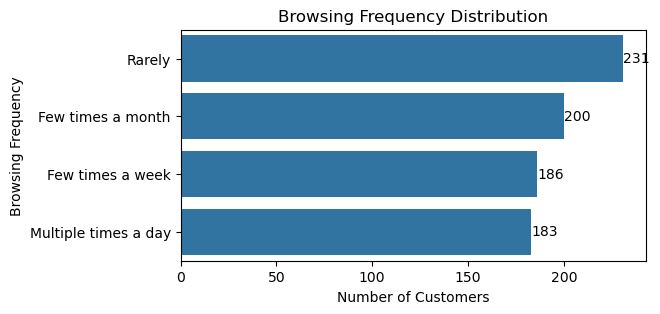

In [296]:
plt.figure(figsize=(6,3))
ax = sns.countplot(y='Browsing_Frequency',data=df,order=df['Browsing_Frequency'].value_counts().index)
for container in ax.containers:
    ax.bar_label(container)

plt.title('Browsing Frequency Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Browsing Frequency')
plt.show()

#### Insight: Most customers browse Amazon rarely, indicating that many users visit the platform only when they have a specific purchase need.

### Task 5.3: Satisfaction Levels

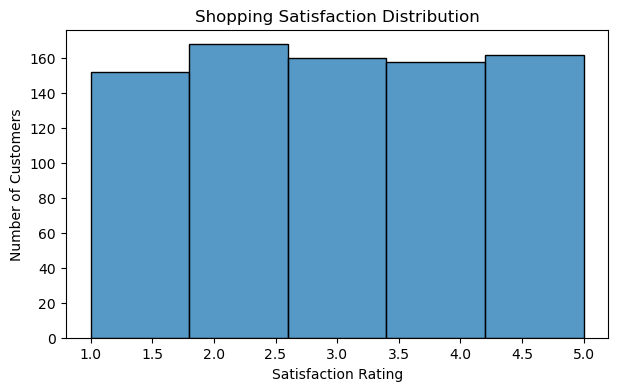

In [297]:
plt.figure(figsize=(7,4))
ax = sns.histplot(df['Shopping_Satisfaction'],bins=5)
plt.title('Shopping Satisfaction Distribution')
plt.xlabel('Satisfaction Rating')
plt.ylabel('Number of Customers')
plt.show()

#### Insight: Customer satisfaction is fairly distributed across all rating levels, showing a mix of positive and negative shopping experiences.

### Task 5.4: Correlation Between Recommendation Usefulness and Satisfaction

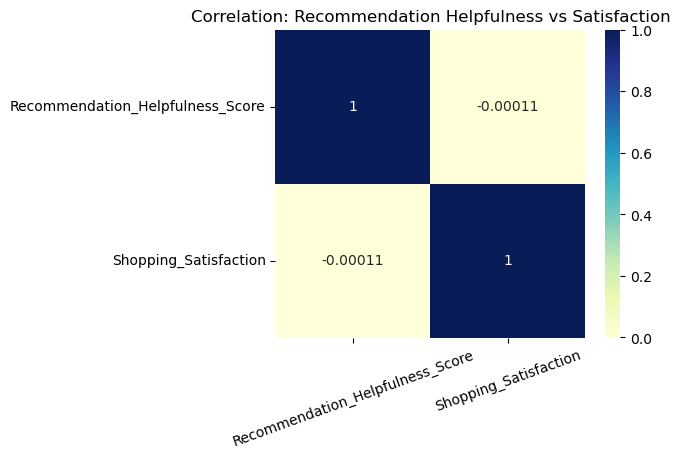

In [299]:
correlation_data = df[['Recommendation_Helpfulness_Score','Shopping_Satisfaction']].corr()
plt.figure(figsize=(5,4))
sns.heatmap(correlation_data,annot=True,cmap='YlGnBu')
plt.title('Correlation: Recommendation Helpfulness vs Satisfaction')
plt.xticks(rotation=20)
plt.show()

#### Insight: Recommendation helpfulness shows almost no correlation with shopping satisfaction, suggesting that other factors have a greater impact on customer experience.

### Task 5.5: Dashboard Summary
### Customer Demographics
##### • The customer base consists of a diverse age group and gender distribution.
### Purchase Behavior
##### • Customers most frequently purchase products from the top product categories identified in the analysis.
##### • Purchase frequency varies from occasional to frequent buyers.
### Customer Segmentation
##### • Customers were grouped into Frequent Buyers, Occasional Shoppers, and At-Risk Customers.
##### • K-Means clustering identified distinct behavioral groups.
### Recommendations & Reviews
##### • Review reliability and helpfulness positively influence customer satisfaction.
##### • Personalized recommendations contribute to customer engagement.
### Business Recommendations
##### • Improve recommendation accuracy using browsing and purchase history.
##### • Promote products with highly trusted reviews.
##### • Target At-Risk Customers with personalized offers and retention campaigns.